In [1]:
import sys, os 
import geopandas as gpd 
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned.geojson')
gdf = gpd.read_file(data_path)

In [2]:
gdf

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,poly_id,image_uid,geometry
0,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,34429.374,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,0,img_0000_c4a77f3e,"POLYGON ((-72.97056 10.61903, -72.97054 10.619..."
1,21,seasonal crops,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,6784.769,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1,img_0000_c4a77f3e,"POLYGON ((-72.96914 10.61884, -72.96915 10.618..."
2,112,urban not continuous,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,12227.436,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,2,img_0000_c4a77f3e,"POLYGON ((-72.96928 10.61948, -72.96931 10.619..."
3,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,19385.187,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,3,img_0000_c4a77f3e,"POLYGON ((-72.97264 10.61976, -72.97273 10.619..."
4,313,fragmented forest,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,5013.914,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,4,img_0000_c4a77f3e,"POLYGON ((-72.96917 10.62053, -72.9691 10.6204..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1959,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,1528.937,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1959,img_0029_37df798b,"POLYGON ((-75.123 3.80901, -75.12297 3.809, -7..."
1960,333,Bare areas,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,0.026,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1960,img_0029_37df798b,"POLYGON ((-75.12391 3.81075, -75.1239 3.81076,..."
1961,232,wooded pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,10536.989,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1961,img_0029_37df798b,"POLYGON ((-75.12278 3.8104, -75.12282 3.81044,..."
1962,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,5139.198,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1962,img_0029_37df798b,"POLYGON ((-75.12367 3.81079, -75.12357 3.81077..."


### Build the COG URL based on the image_uid 

We need to build the COG URL so we can query the image stats for each polygon.

In [3]:
base_url = os.path.join(os.getcwd(), '..', 'data', 'images', 'cog')
row = gdf.iloc[85]
cog_url = f"{base_url}/{row['image_uid']}.tif"
geom = [row.geometry.__geo_interface__]
row['image_uid']

'img_0004_befb8cbc'

## Reprojection and computation 

First, we handle the reprojection issue. The drone images are in a local projected coordinate system of WGS84, but the geometry is in degrees following EPSG:4326, so we need to project the geometry into the CRS of the raster (it is easier this way than the other way around). After that, we take advantage of the tiles we constructed earlier with COG - we only fetch the part of the image for that polygon. Once we have that, we have the band data. We have 3 bands in the image.

We observed mainly two main artifacts in the drone images: 
- First: there are no-data pixels in the drone images, especially near the boundaries and sometimes randomly in the middle, mostly because of how the drone image was processed and collected - maybe there were no overlapping pixels.
- We also observed that the pixel values are 0 in random areas, possibly seeming like faulty pixels, or we can say invalid pixels because the values were not even in the 0 to 255 range. 

Hence, to handle them, we first used a function from numpy's masked array that helps us identify the invalid pixels, and then we filtered the nodata values in the raster, which helped us remove those no-data pixels. We will study in depth whether they would have any impact on the mean computations!

In [4]:

import rasterio 
from rasterio.mask import mask
import numpy as np
from skimage import color
from scipy.stats import circmean, circstd

with rasterio.open(cog_url) as src:
    print("Raster CRS:", src.crs)
    print("Raster bounds:", src.bounds)
    
    print("\nOriginal geometry CRS:", gdf.crs)
    print("Original geometry bounds:", row.geometry.bounds)
    
    geom_gdf = gpd.GeoDataFrame([row], geometry='geometry', crs=gdf.crs)
    geom_reprojected = geom_gdf.to_crs(src.crs)
    geom_transformed = [geom_reprojected.geometry.iloc[0].__geo_interface__]
    
    print("\nTransformed bounds:", geom_reprojected.geometry.iloc[0].bounds)
    
    masked_data, _ = mask(src, geom_transformed, crop=True, all_touched=False)

    r_band = masked_data[0]
    g_band = masked_data[1]
    b_band = masked_data[2]
    
    is_masked = np.ma.isMaskedArray(r_band)
    
    if is_masked:
        valid_mask = ~(r_band.mask | g_band.mask | b_band.mask)
    else:
        nodata = src.nodata if src.nodata is not None else -9999
        valid_mask = (r_band != nodata) & (g_band != nodata) & (b_band != nodata)
    
    r_valid = r_band[valid_mask]
    g_valid = g_band[valid_mask]
    b_valid = b_band[valid_mask]
    
    stats = {}
    
    if r_valid.size > 0:
        stats['r_mean'] = float(np.mean(r_valid))
        stats['r_median'] = float(np.median(r_valid))
        stats['r_std'] = float(np.std(r_valid))
        stats['r_var'] = float(np.var(r_valid))
        
        stats['g_mean'] = float(np.mean(g_valid))
        stats['g_median'] = float(np.median(g_valid))
        stats['g_std'] = float(np.std(g_valid))
        stats['g_var'] = float(np.var(g_valid))
        
        stats['b_mean'] = float(np.mean(b_valid))
        stats['b_median'] = float(np.median(b_valid))
        stats['b_std'] = float(np.std(b_valid))
        stats['b_var'] = float(np.var(b_valid))
        
        r_g = np.divide(r_valid, g_valid, where=g_valid != 0, out=np.full_like(r_valid, np.nan, dtype=float))
        r_b = np.divide(r_valid, b_valid, where=b_valid != 0, out=np.full_like(r_valid, np.nan, dtype=float))
        g_b = np.divide(g_valid, b_valid, where=b_valid != 0, out=np.full_like(g_valid, np.nan, dtype=float))
        
        stats['r_g_mean'] = float(np.nanmean(r_g))
        stats['r_g_std'] = float(np.nanstd(r_g))
        stats['r_b_mean'] = float(np.nanmean(r_b))
        stats['r_b_std'] = float(np.nanstd(r_b))
        stats['g_b_mean'] = float(np.nanmean(g_b))
        stats['g_b_std'] = float(np.nanstd(g_b))
        
        r_minus_g = r_valid - g_valid
        g_minus_b = g_valid - b_valid
        
        stats['r_minus_g_mean'] = float(np.mean(r_minus_g))
        stats['r_minus_g_std'] = float(np.std(r_minus_g))
        stats['g_minus_b_mean'] = float(np.mean(g_minus_b))
        stats['g_minus_b_std'] = float(np.std(g_minus_b))
        
        rgb_stack = np.stack([r_band[valid_mask], g_band[valid_mask], b_band[valid_mask]], axis=-1)
        rgb_norm = rgb_stack / 255.0 if rgb_stack.max() > 1 else rgb_stack
        
        hsv = color.rgb2hsv(rgb_norm.reshape(1, -1, 3)).reshape(-1, 3)
        stats['hsv_s_mean'] = float(np.mean(hsv[:, 1]))
        stats['hsv_v_mean'] = float(np.mean(hsv[:, 2]))
        
        hue_rad = hsv[:, 0] * 2 * np.pi
        stats['hsv_h_mean'] = float(circmean(hue_rad))
        stats['hsv_h_std'] = float(circstd(hue_rad))
        
        lab = color.rgb2lab(rgb_norm.reshape(1, -1, 3)).reshape(-1, 3)
        stats['lab_l_mean'] = float(np.mean(lab[:, 0]))
        stats['lab_a_mean'] = float(np.mean(lab[:, 1]))
        stats['lab_b_mean'] = float(np.mean(lab[:, 2]))
        
        denom = g_valid + r_valid - b_valid
        vari = np.divide(g_valid - r_valid, denom, where=denom != 0, out=np.full_like(g_valid, np.nan, dtype=float))
        
        stats['vari_mean'] = float(np.nanmean(vari))
        stats['vari_std'] = float(np.nanstd(vari))
    else:
        stats = {k: np.nan for k in [
            'r_mean', 'r_median', 'r_std', 'r_var',
            'g_mean', 'g_median', 'g_std', 'g_var',
            'b_mean', 'b_median', 'b_std', 'b_var',
            'r_g_mean', 'r_g_std', 'r_b_mean', 'r_b_std', 'g_b_mean', 'g_b_std',
            'r_minus_g_mean', 'r_minus_g_std', 'g_minus_b_mean', 'g_minus_b_std',
            'hsv_s_mean', 'hsv_v_mean', 'hsv_h_mean', 'hsv_h_std',
            'lab_l_mean', 'lab_a_mean', 'lab_b_mean',
            'vari_mean', 'vari_std'
        ]}
    
    print(f"Total features: {len(stats)}")
    print(stats)

Raster CRS: EPSG:31972
Raster bounds: BoundingBox(left=798377.2564287523, bottom=1258272.372298243, right=798809.5453630312, top=1258639.7511624014)

Original geometry CRS: EPSG:4326
Original geometry bounds: (-72.26428410779879, 11.37249112018623, -72.2641426344344, 11.372635034273511)

Transformed bounds: (798583.919650044, 1258572.9447205674, 798599.2670122238, 1258588.8172280705)
Total features: 31
{'r_mean': 121.84823346118776, 'r_median': 173.0, 'r_std': 105.68231089007693, 'r_var': 11168.750835066874, 'g_mean': 133.42882508308026, 'g_median': 189.0, 'g_std': 107.49028189935403, 'g_var': 11554.160702802597, 'b_mean': 136.12689709350957, 'b_median': 220.0, 'b_std': 109.4135689620311, 'b_var': 11971.329073009138, 'r_g_mean': 0.8940113924298428, 'r_g_std': 0.21403331852296584, 'r_b_mean': 0.9227795078957705, 'r_b_std': 0.36955887752244376, 'g_b_mean': 1.021731206886354, 'g_b_std': 0.5978237012094993, 'r_minus_g_mean': 144.11674754903808, 'r_minus_g_std': 117.93357782027627, 'g_minus

### Build the features 

Here we try to extract different types of statistics from the image in our polygon. We have already calculated the area of the polygon that can be used as a feature, and here we are using mean, std, var in each band as well as some band indices, green index, and color profile!

In [3]:
from src.stats import compute_raster_stats

In [4]:
gdf_with_stats = compute_raster_stats(gdf, base_url='/home/krschap/Jupyter/ubs/ml/mlproject1/landcoverclassification/data/images/cog')

Processing polygons:  35%|███▍      | 679/1964 [06:35<02:52,  7.43it/s]  

Failed to process polygon at index 669: Input shapes do not overlap raster.
Failed to process polygon at index 670: Input shapes do not overlap raster.
Failed to process polygon at index 671: Input shapes do not overlap raster.
Failed to process polygon at index 672: Input shapes do not overlap raster.


Processing polygons:  40%|████      | 788/1964 [06:39<00:23, 49.01it/s]

Failed to process polygon at index 783: Input shapes do not overlap raster.
Failed to process polygon at index 785: Input shapes do not overlap raster.


Processing polygons:  48%|████▊     | 942/1964 [06:48<00:56, 18.25it/s]

Failed to process polygon at index 946: Input shapes do not overlap raster.
Failed to process polygon at index 947: Input shapes do not overlap raster.
Failed to process polygon at index 948: Input shapes do not overlap raster.
Failed to process polygon at index 949: Input shapes do not overlap raster.
Failed to process polygon at index 950: Input shapes do not overlap raster.
Failed to process polygon at index 951: Input shapes do not overlap raster.
Failed to process polygon at index 952: Input shapes do not overlap raster.


Processing polygons: 100%|██████████| 1964/1964 [20:46<00:00,  1.58it/s]  


In [5]:
gdf_with_stats

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,...,r_std,r_var,g_mean,g_median,g_std,g_var,b_mean,b_median,b_std,b_var
0,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,34429.374,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,31.204851,973.742726,127.326987,128.0,24.155410,583.483815,88.046773,89.0,28.192019,794.789929
1,21,seasonal crops,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,6784.769,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,33.014478,1089.955725,112.434591,109.0,31.271098,977.881567,92.731403,91.0,29.475412,868.799885
2,112,urban not continuous,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,12227.436,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,32.730920,1071.313121,127.324138,128.0,29.872697,892.378055,68.139833,62.0,38.685957,1496.603306
3,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,19385.187,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,32.866169,1080.185062,127.948752,128.0,23.740170,563.595648,84.136398,81.0,32.283869,1042.248166
4,313,fragmented forest,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,5013.914,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,32.696275,1069.046431,110.251933,110.0,33.226429,1103.995562,56.357108,53.0,27.970275,782.336267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1959,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,1528.937,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,30.599355,936.320508,103.539958,110.0,29.934403,896.068492,53.912820,55.0,23.200185,538.248594
1960,333,Bare areas,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,0.026,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,30.598203,936.250000,70.500000,78.0,31.951787,1020.916667,43.055556,43.5,21.879651,478.719136
1961,232,wooded pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,10536.989,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,32.532493,1058.363119,66.563878,68.0,29.660503,879.745450,38.797581,34.0,26.099047,681.160241
1962,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,5139.198,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,27.100222,734.422016,75.457244,77.0,23.985616,575.309798,48.630724,49.0,21.899011,479.566690


In [6]:
gdf_with_stats.to_file(os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats.geojson'))

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

mean_stats = {k: v for k, v in stats.items() if k in ["r_mean", "g_mean", "b_mean"]}

df_mean = pd.Series(mean_stats).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
df_mean.plot(kind='bar')
plt.title('Mean Values of Extracted Features')
plt.ylabel('Mean Value')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('mean_features_bar_chart.png')

/tmp/ipykernel_8717/2267291875.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data,
/tmp/ipykernel_8717/2267291875.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data,


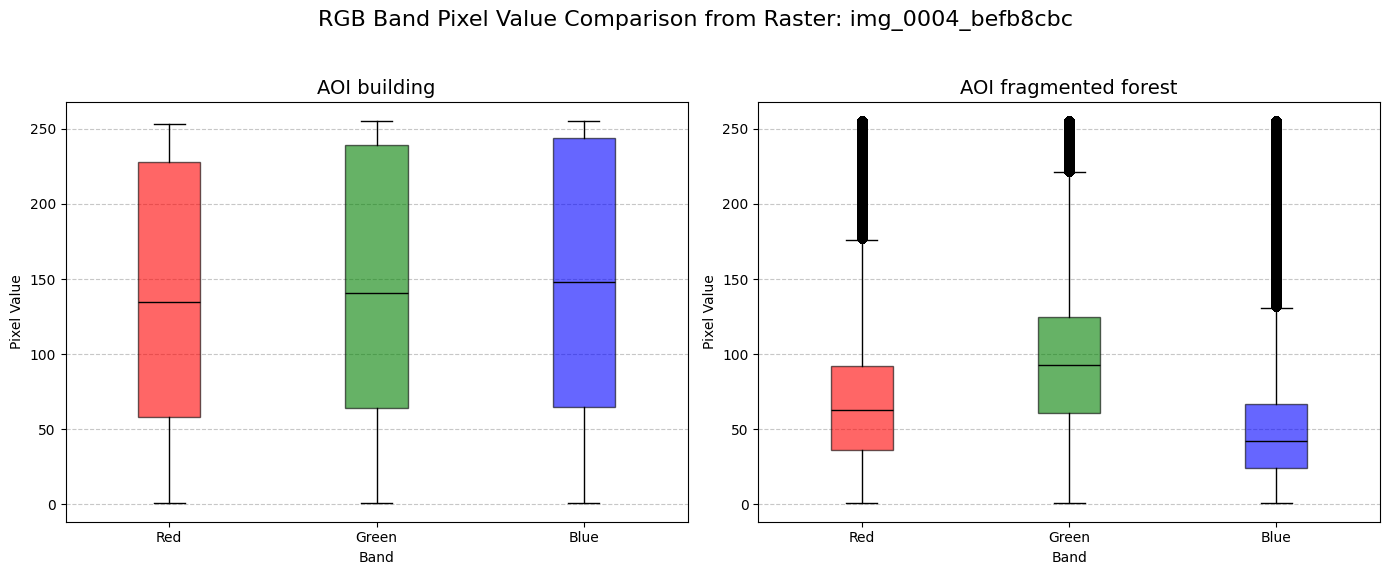

In [46]:
def extract_valid_data(src, row, gdf_crs):
    
    geom_gdf = gpd.GeoDataFrame([row], geometry='geometry', crs=gdf_crs)
    geom_reprojected = geom_gdf.to_crs(src.crs)
    geom_transformed = [geom_reprojected.geometry.iloc[0].__geo_interface__]
    
    masked_data, _ = mask(src, geom_transformed, crop=True, all_touched=False)
    r_band, g_band, b_band = masked_data[0], masked_data[1], masked_data[2]

    nodata = src.nodata if src.nodata is not None else -9999
    valid_mask = np.ones(r_band.shape, dtype=bool)
    
    if np.ma.isMaskedArray(r_band):
        valid_mask = ~(r_band.mask | g_band.mask | b_band.mask)
    else:
        valid_mask &= (r_band != nodata) & (g_band != nodata) & (b_band != nodata)
        
    valid_mask &= (r_band != 0) & (g_band != 0) & (b_band != 0)

    r_valid = r_band[valid_mask].astype(float)
    g_valid = g_band[valid_mask].astype(float)
    b_valid = b_band[valid_mask].astype(float)

    return [r_valid, g_valid, b_valid]


row_1 = gdf.iloc[85]
row_2 = gdf.iloc[124]
cog_url = f"{base_url}/{'img_0004_befb8cbc'}.tif" # Use the image_uid from the first row

band_labels = ['Red', 'Green', 'Blue']
band_colors = ['red', 'green', 'blue']

with rasterio.open(cog_url) as src:
        data_1 = extract_valid_data(src, row_1, gdf.crs)
        data_2 = extract_valid_data(src, row_2, gdf.crs)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

titles = [f"AOI {row_1.OBSERV}", f"AOI {row_2.OBSERV}"]
datasets = [data_1, data_2]

for ax, data, title in zip(axes, datasets, titles):
    
    if any(arr.size > 0 for arr in data):
        bp = ax.boxplot(data, 
                         labels=band_labels, 
                         patch_artist=True,
                         medianprops={'color': 'black'})
        
        # Apply colors to boxes
        for box, color in zip(bp['boxes'], band_colors):
            box.set_facecolor(color)
            box.set_alpha(0.6)
            
        ax.set_title(title, fontsize=14)
        ax.set_ylabel('Pixel Value')
        ax.set_xlabel('Band')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
    else:
        ax.set_title(f"{title} (No Valid Data Found)", fontsize=14)
        ax.axis('off')

fig.suptitle(f"RGB Band Pixel Value Comparison from Raster: {row_1['image_uid']}", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('two_aoi_box_plots_comparison.png')

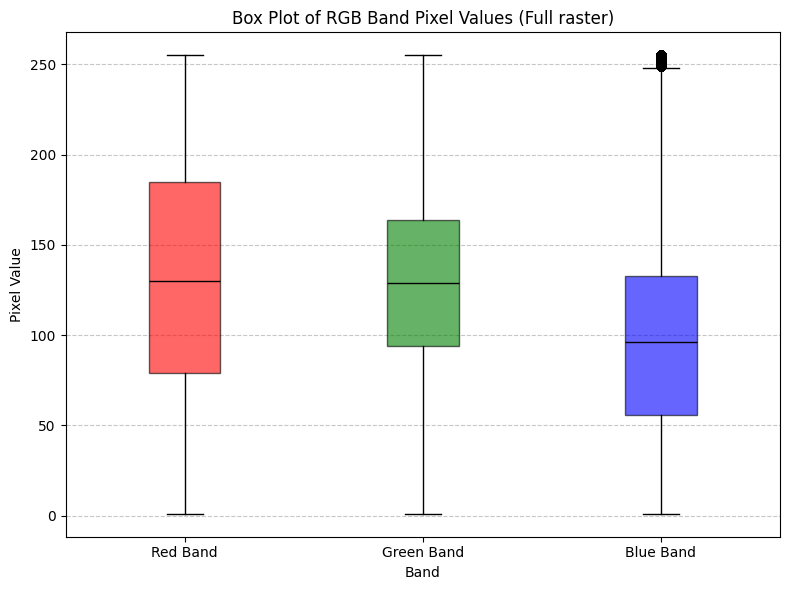

In [20]:
with rasterio.open(cog_url) as src:

    r_band = src.read(1)
    g_band = src.read(2)
    b_band = src.read(3)

    is_masked = np.ma.isMaskedArray(r_band)
    
    if is_masked:
        valid_mask = ~(r_band.mask | g_band.mask | b_band.mask)
    else:
        nodata = src.nodata if src.nodata is not None else -9999
        valid_mask = (r_band != nodata) & (g_band != nodata) & (b_band != nodata) & (r_band != 0) & (g_band != 0) & (b_band != 0)
    
    r_valid = r_band[valid_mask]
    g_valid = g_band[valid_mask]
    b_valid = b_band[valid_mask]

    band_data = [r_valid, g_valid, b_valid]
    band_labels = ['Red Band', 'Green Band', 'Blue Band']
    band_colors = ['red', 'green', 'blue']
    
    plt.figure(figsize=(8, 6))
    
    bp = plt.boxplot(band_data, 
                     tick_labels=band_labels, 
                     patch_artist=True,
                     medianprops={'color': 'black'})
    
    for box, color in zip(bp['boxes'], band_colors):
        box.set_facecolor(color)
        box.set_alpha(0.6)
    
    plt.title('Box Plot of RGB Band Pixel Values (Full raster)')
    plt.ylabel('Pixel Value')
    plt.xlabel('Band')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()